<a href="https://colab.research.google.com/github/Roll1ngo/Authorization_and_authentication_synopsis/blob/master/yolo8_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
HOME = os.getcwd()
print(HOME)


/content


In [3]:
!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 33.6/78.2 GB disk)


In [4]:
from ultralytics import YOLO

from IPython.display import display, Image

!mkdir {HOME}\datasets
%cd {HOME}\datasets

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="9cBmz9pmN1YhVsvyH05Z")
project = rf.workspace("yolo8-dnawx").project("license-plates-us-eu-1tufg")
version = project.version(2)
dataset = version.download("yolov8")

/contentdatasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plates-2 in yolov8:: 100%|██████████| 711/711 [00:00<00:00, 3433.92it/s]


In [5]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

100% 21.5M/21.5M [00:00<00:00, 144MB/s] 
New https://pypi.org/project/ultralytics/8.2.79 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/contentdatasets/License-Plates-2/data.yaml, epochs=25, patience=50, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, stream_buffer=F

/content


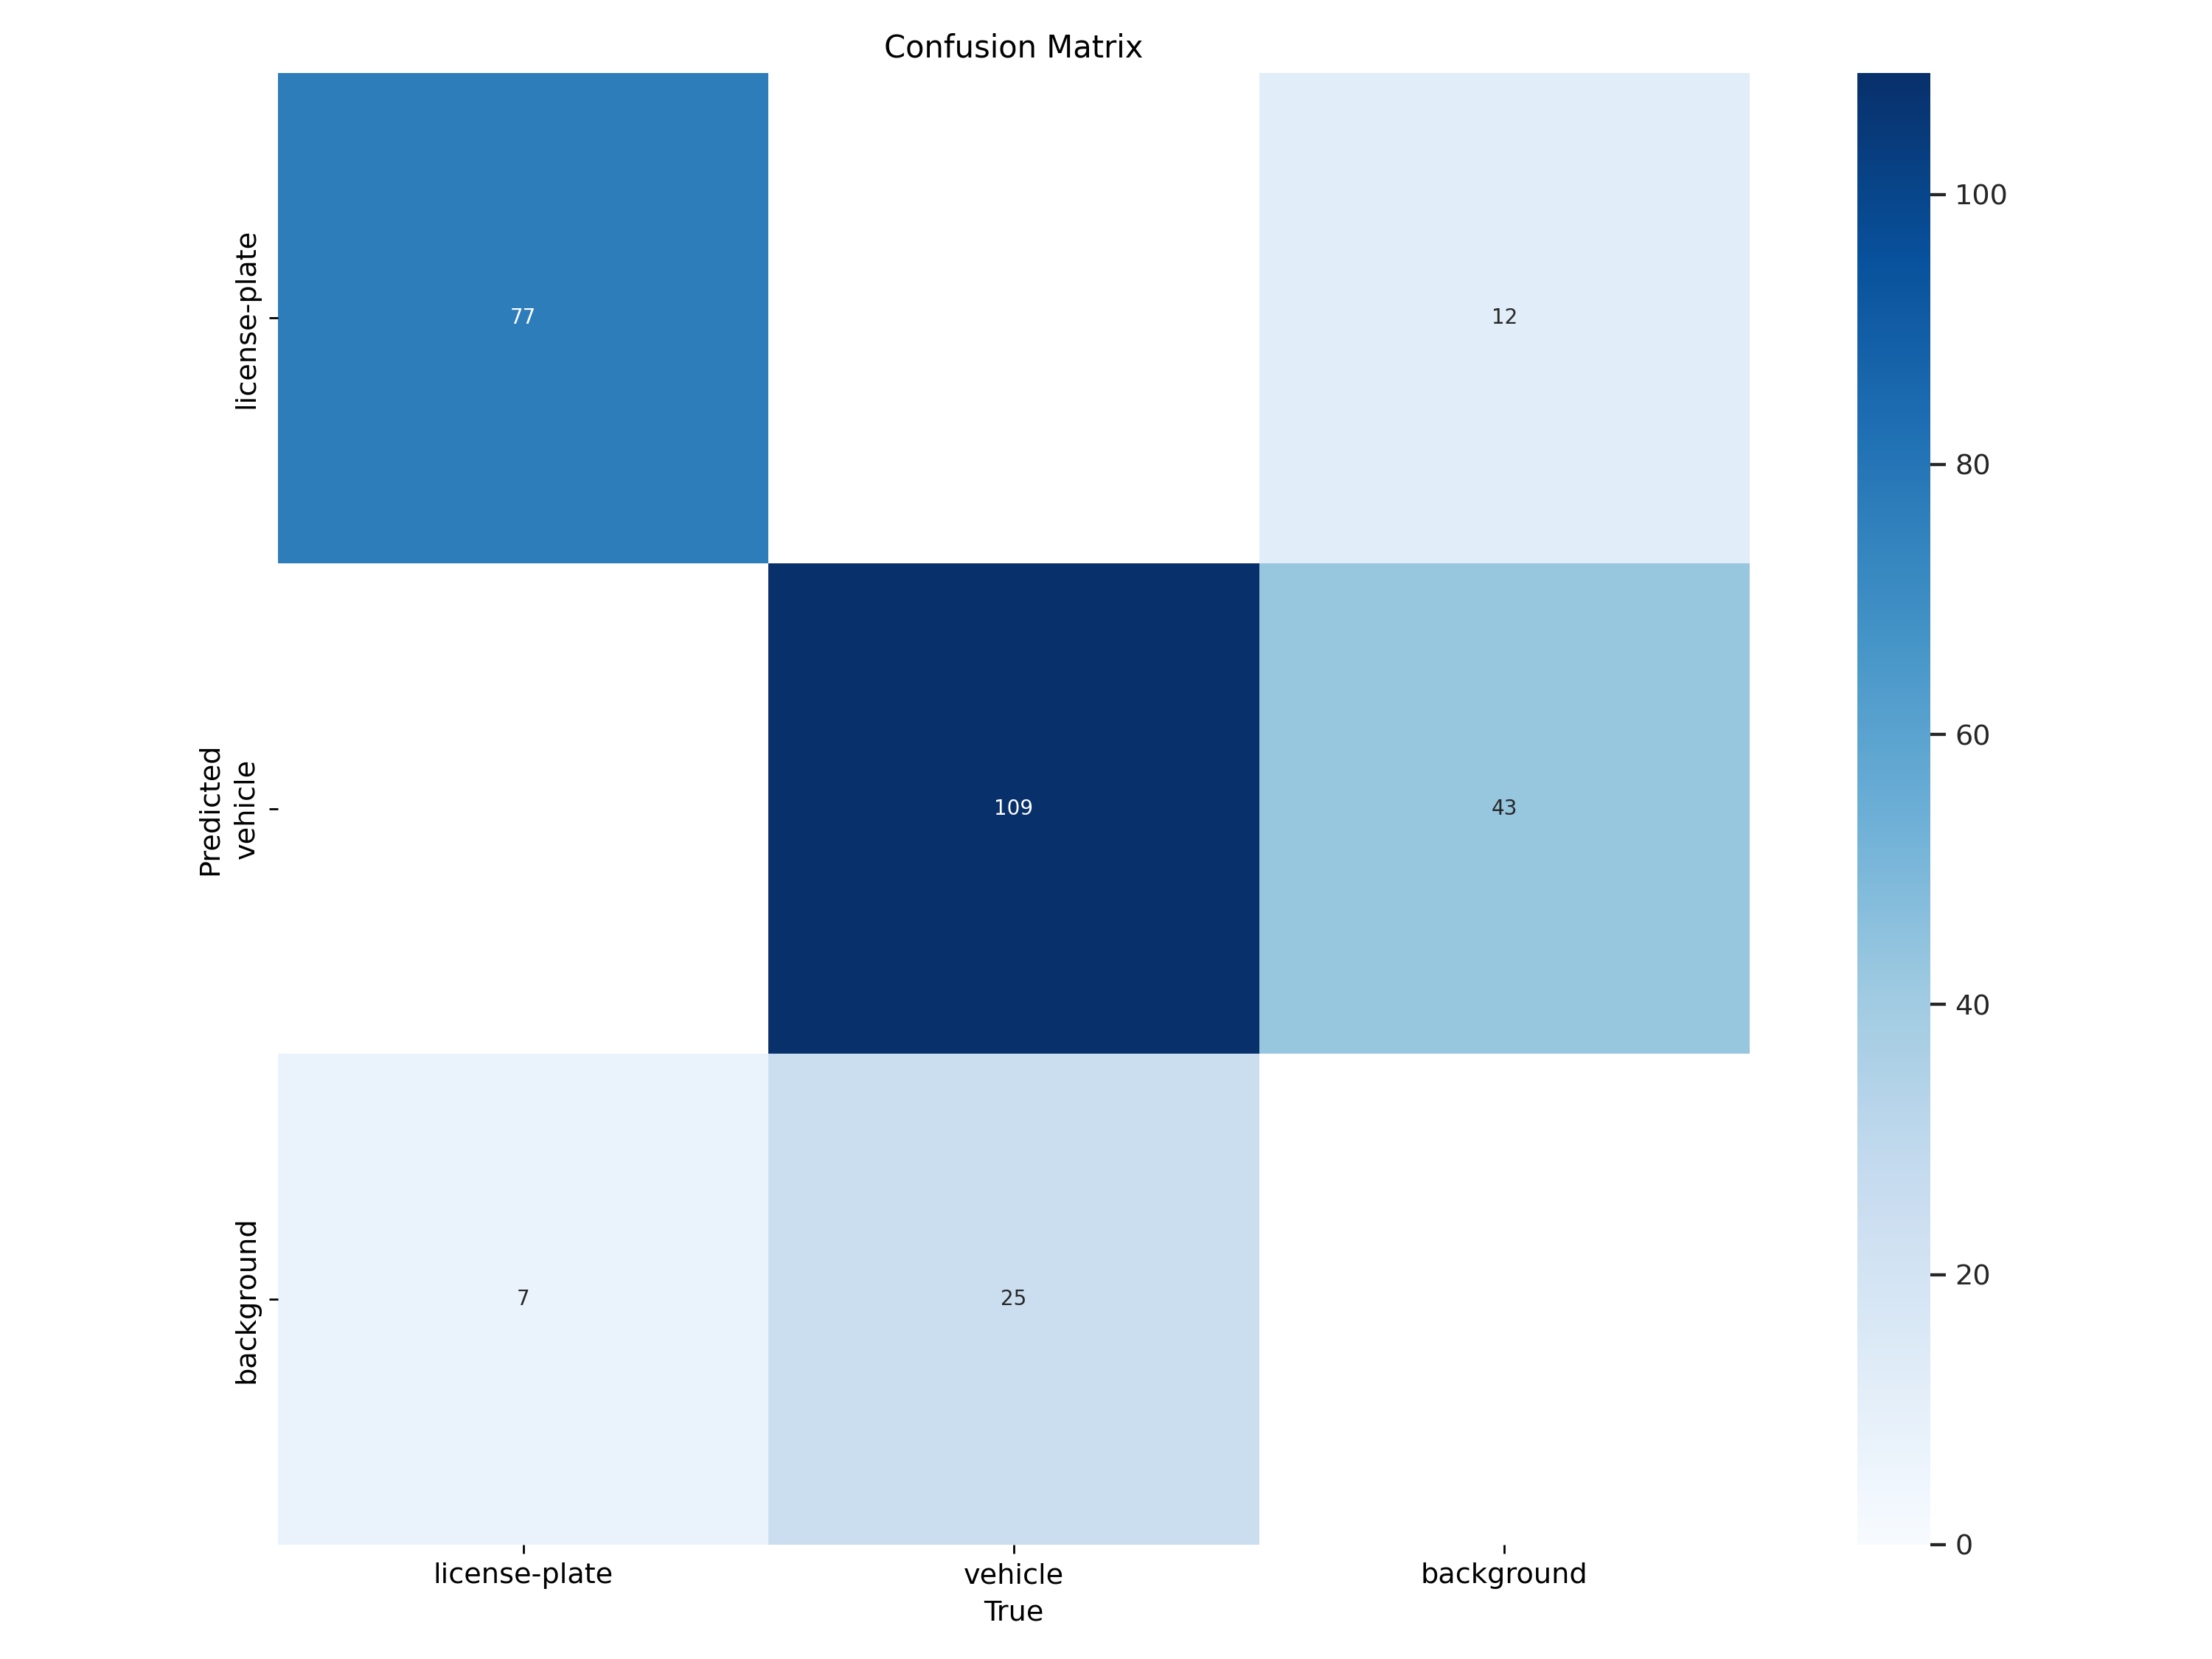

In [11]:
Home_real = '/contentdatasets'
%cd {HOME}
Image(filename=f'{Home_real}/runs/detect/train/confusion_matrix.png', width=600)

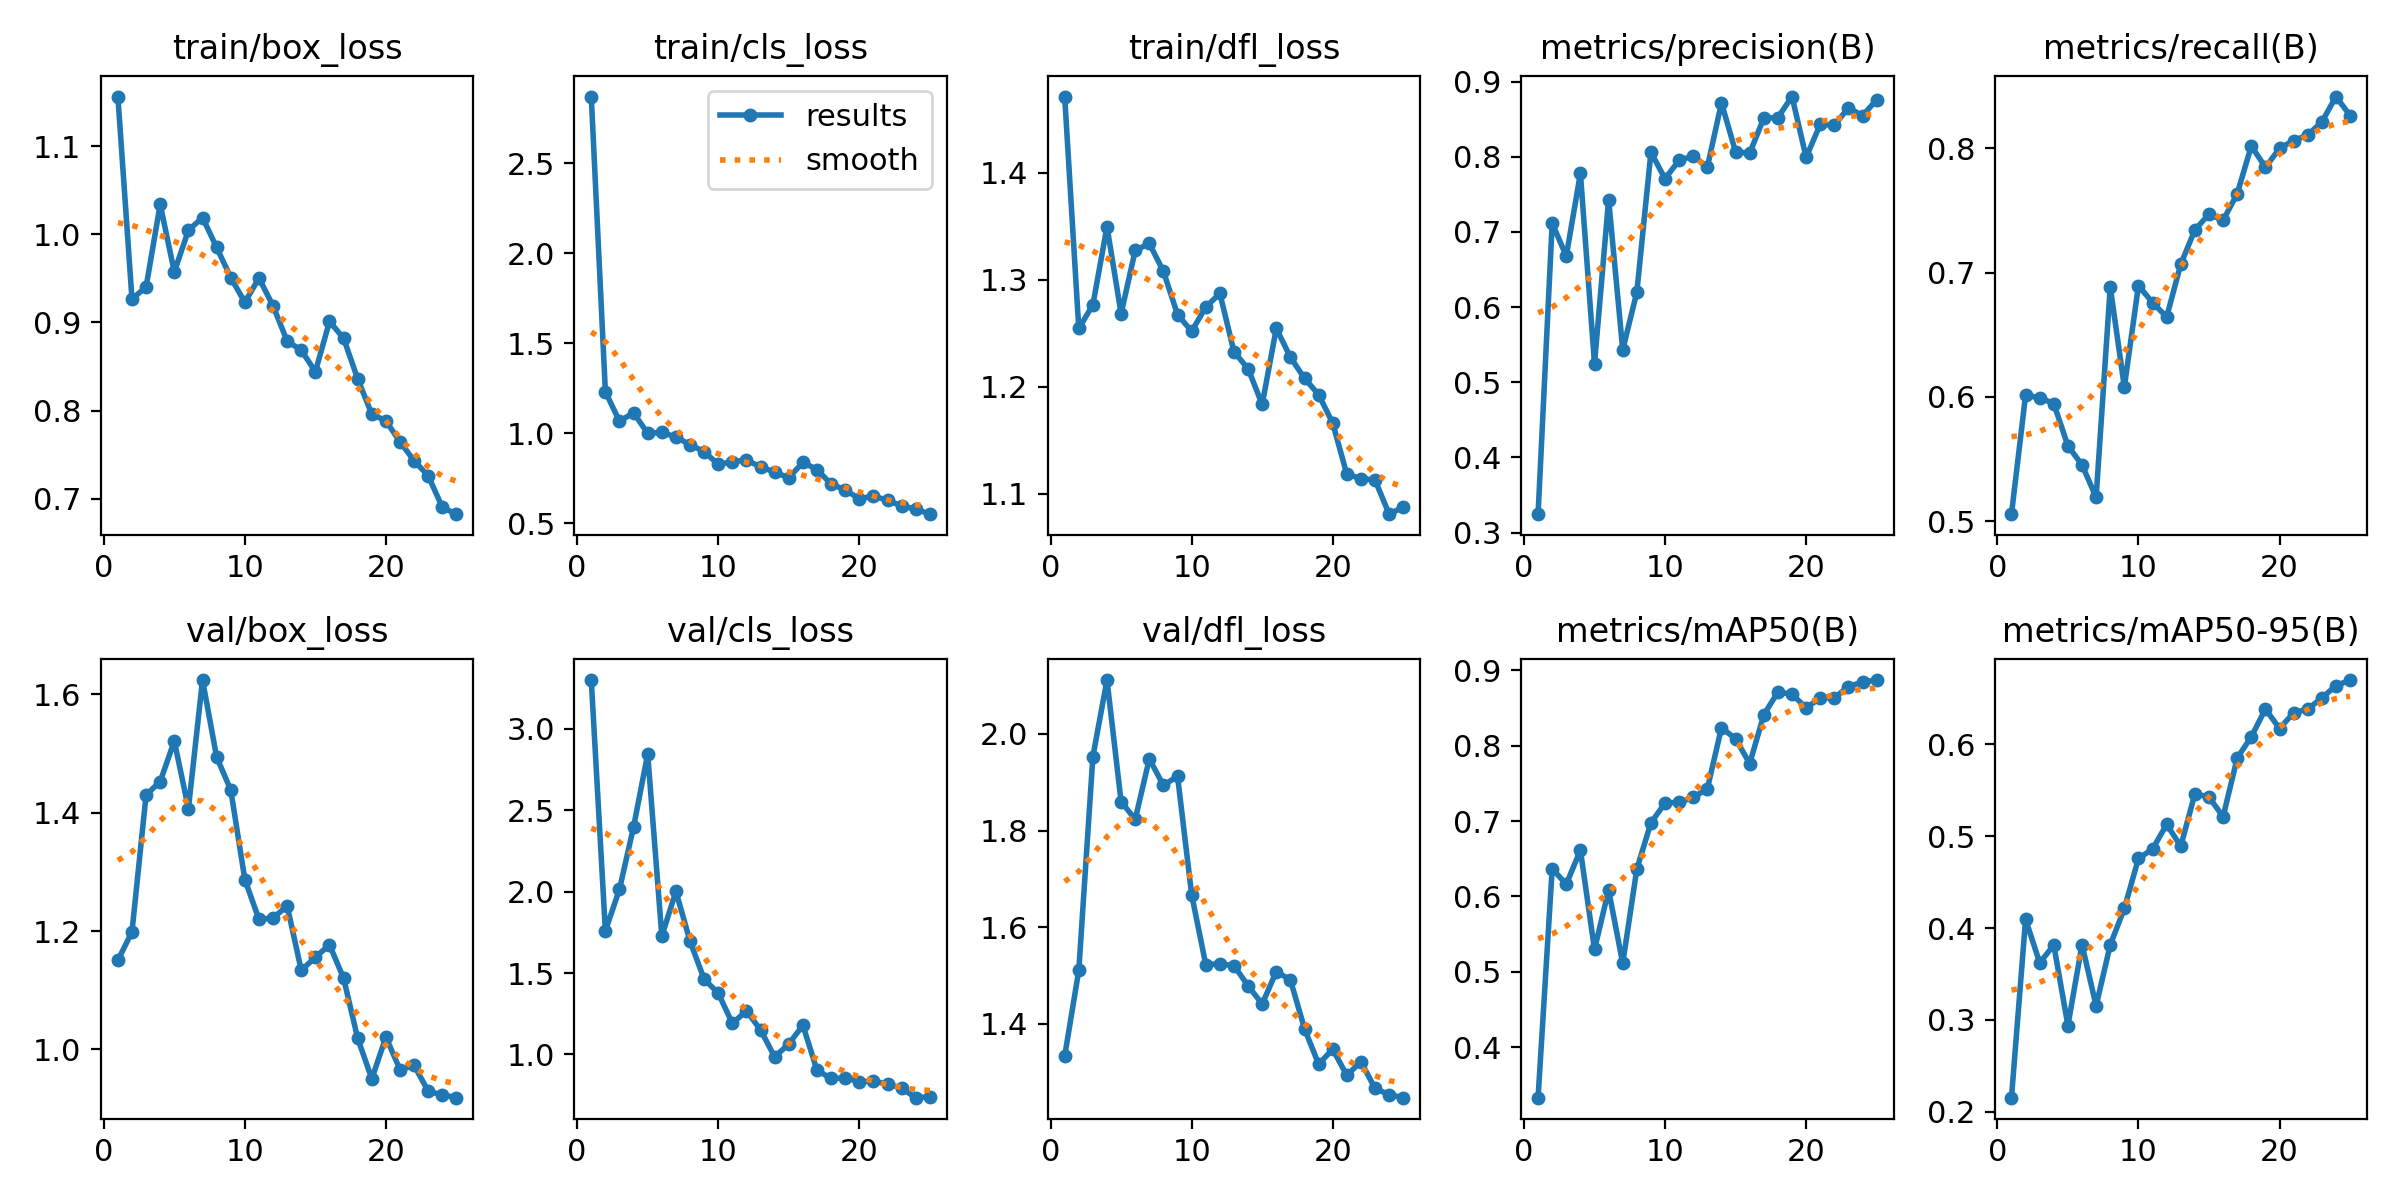

In [12]:
Image(filename=f'{Home_real}/runs/detect/train/results.png', width=600)

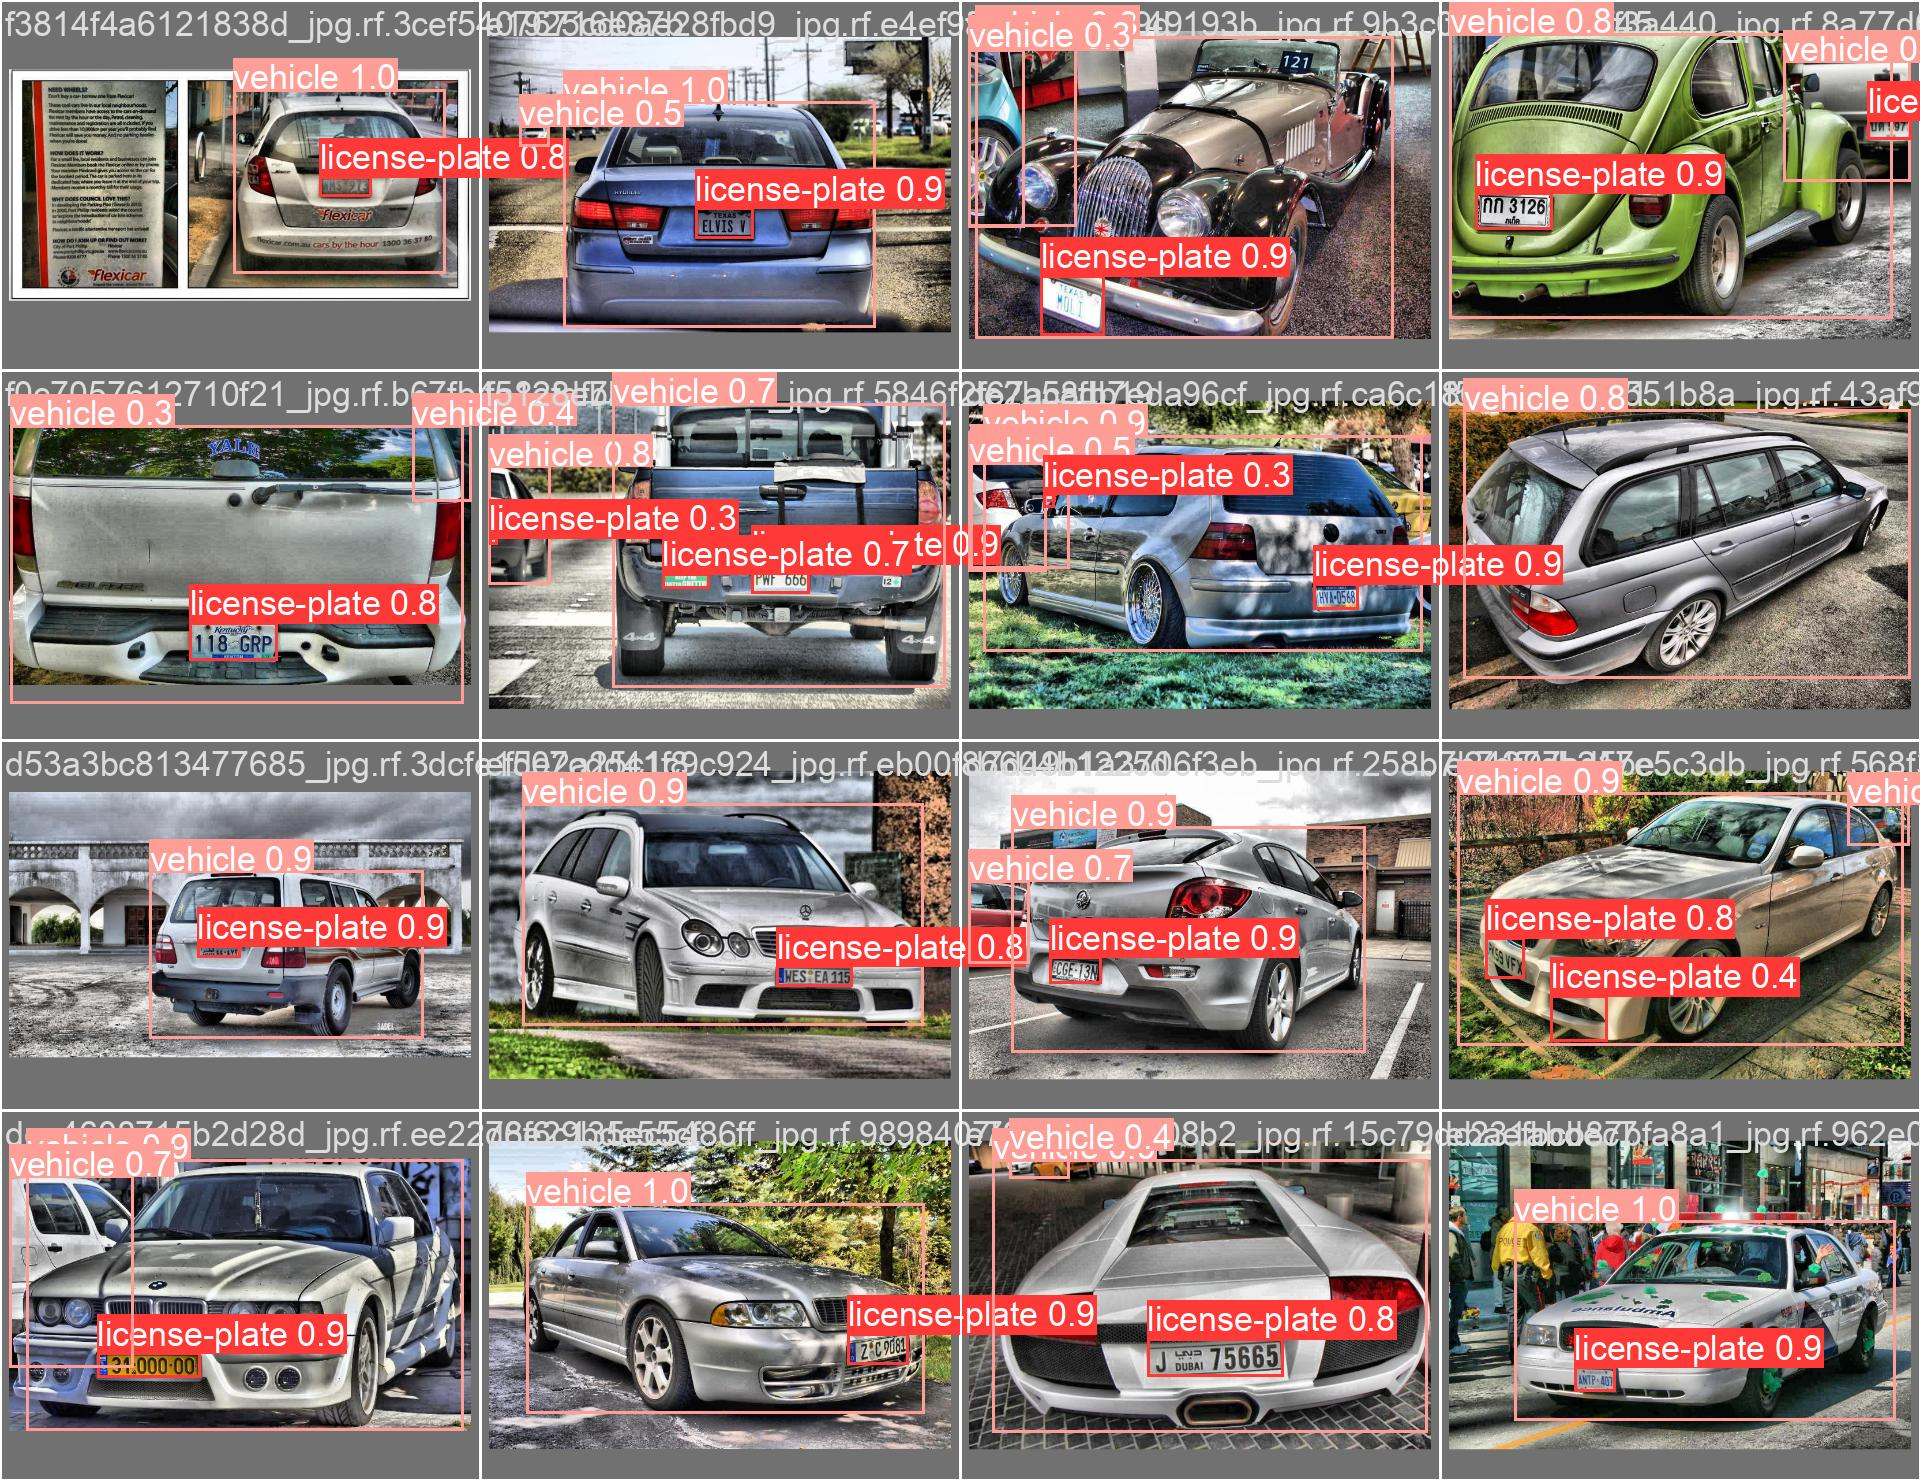

In [13]:
Image(filename=f'{Home_real}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [17]:
project.version(dataset.version).deploy(model_type="yolov8", model_path=f"{Home_real}/runs/detect/train/")

View the status of your deployment at: https://app.roboflow.com/yolo8-dnawx/license-plates-us-eu-1tufg/2


AttributeError: 'NoneType' object has no attribute 'predict'